# **Chocolates Sales Analysis(2023-24)**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Data Loading**

In [2]:
sales = pd.read_csv('/content/sales.csv')
calendar = pd.read_csv('/content/calendar.csv')
customers = pd.read_csv('/content/customers.csv')
products = pd.read_csv('/content/products.csv')
stores = pd.read_csv('/content/stores.csv')

# **DATA VISUALIZATION**

In [3]:
sales.head()


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [4]:
calendar.head()

,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [5]:
products.head()

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


In [6]:
customers.head()

,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31


In [7]:
stores.head()

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online


In [8]:
sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  object 
 1   order_date   1000000 non-null  object 
 2   product_id   1000000 non-null  object 
 3   store_id     1000000 non-null  object 
 4   customer_id  1000000 non-null  object 
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 83.9+ MB


In [9]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         731 non-null    object
 1   year         731 non-null    int64 
 2   month        731 non-null    int64 
 3   day          731 non-null    int64 
 4   week         731 non-null    int64 
 5   day_of_week  731 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 34.4+ KB


In [10]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    int64 
 5   weight_g       200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


In [11]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     50000 non-null  object
 1   age             50000 non-null  int64 
 2   gender          50000 non-null  object
 3   loyalty_member  50000 non-null  int64 
 4   join_date       50000 non-null  object
dtypes: int64(2), object(3)
memory usage: 1.9+ MB


In [12]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    100 non-null    object
 1   store_name  100 non-null    object
 2   city        100 non-null    object
 3   country     100 non-null    object
 4   store_type  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


In [13]:
sales.describe()

,quantity,unit_price,discount,revenue,cost,profit
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565
std,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760
min,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000
25%,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000
50%,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000
75%,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000
max,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000


In [14]:
products.describe()

,cocoa_percent,weight_g
count,200.000000,200.000000
mean,69.150000,107.500000
std,14.623499,50.898954
min,50.000000,50.000000
25%,50.000000,80.000000
50%,70.000000,100.000000
75%,80.000000,120.000000
max,90.000000,200.000000


In [15]:
customers.describe()

,age,loyalty_member
count,50000.000000,50000.000000
mean,44.026100,0.502080
std,15.328333,0.500001
min,18.000000,0.000000
25%,31.000000,0.000000
50%,44.000000,1.000000
75%,57.000000,1.000000
max,70.000000,1.000000


In [16]:
calendar.describe()

,year,month,day,week,day_of_week
count,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2023.500684,6.519836,15.738714,26.465116,2.997264
std,0.500342,3.451913,8.809949,15.076602,2.004787
min,2023.000000,1.000000,1.000000,1.000000,0.000000
25%,2023.000000,4.000000,8.000000,13.000000,1.000000
50%,2024.000000,7.000000,16.000000,26.000000,3.000000
75%,2024.000000,10.000000,23.000000,39.500000,5.000000
max,2024.000000,12.000000,31.000000,52.000000,6.000000


In [17]:
stores.describe()

,store_id,store_name,city,country,store_type
count,100,100,100,100,100
unique,100,100,7,6,4
top,S001,Chocolate Store 1,Toronto,Canada,Airport
freq,1,1,18,20,30


In [18]:
sales.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0


In [19]:
calendar.isnull().sum()

,0
date,0
year,0
month,0
day,0
week,0
day_of_week,0


In [20]:
products.isnull().sum()

,0
product_id,0
product_name,0
brand,0
category,0
cocoa_percent,0
weight_g,0


In [21]:
customers.isnull().sum()

,0
customer_id,0
age,0
gender,0
loyalty_member,0
join_date,0


In [22]:
stores.isnull().sum()

,0
store_id,0
store_name,0
city,0
country,0
store_type,0


### **Data Cleaning**

In [23]:
# Convert dates
sales['order_date'] = pd.to_datetime(sales['order_date'])
calendar['date'] = pd.to_datetime(calendar['date'])



In [24]:
sales.info()
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   order_id     1000000 non-null  object        
 1   order_date   1000000 non-null  datetime64[ns]
 2   product_id   1000000 non-null  object        
 3   store_id     1000000 non-null  object        
 4   customer_id  1000000 non-null  object        
 5   quantity     1000000 non-null  int64         
 6   unit_price   1000000 non-null  float64       
 7   discount     1000000 non-null  float64       
 8   revenue      1000000 non-null  float64       
 9   cost         1000000 non-null  float64       
 10  profit       1000000 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 83.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype

In [25]:
df = sales.merge(products, on = 'product_id',how = 'left')
df = df.merge(customers,on='customer_id',how = 'left')
df = df.merge(stores,on = 'store_id',how = 'left')
df = df.merge(calendar,left_on='order_date',right_on = 'date',how = 'left')

In [26]:
df.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,store_name,city,country,store_type,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,Chocolate Store 93,Sydney,UK,Airport,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,Chocolate Store 65,New York,Australia,Retail,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,Chocolate Store 78,London,UK,Airport,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,Chocolate Store 88,Toronto,USA,Retail,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,Chocolate Store 54,London,Canada,Online,2024-09-24,2024,9,24,39,1


In [27]:
df.shape

(1000000, 30)

In [28]:
df.columns

Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit',
       'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'age',
       'gender', 'loyalty_member', 'join_date', 'store_name', 'city',
       'country', 'store_type', 'date', 'year', 'month', 'day', 'week',
       'day_of_week'],
      dtype='object')

In [29]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0


In [30]:
df = df.dropna(subset=['product_name',
                       'brand','category',
                       'cocoa_percent','weight_g'])

In [31]:
df.isnull().sum()

,0
order_id,0
order_date,0
product_id,0
store_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
revenue,0
cost,0


In [32]:
df.shape


(990236, 30)

# **EXPLORATORY DATA ANALYTICS**

**Top Customers**

In [33]:
top_customers = df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)
top_customers

,revenue
customer_id,
C033309,1183.16
C044802,1123.37
C026507,1104.10
C020498,1100.16
C028533,1099.16
C019742,1096.15
C040736,1095.84
C009919,1095.14
C029306,1085.62


*A small group of customers contributes significantly to total revenue, indicating the importance of customer retention strategies*

**Store Performance**

In [34]:
store_perf = df.groupby('store_type')['revenue'].sum().sort_values(ascending=False)
store_perf

,revenue
store_type,
Airport,7539629.88
Mall,6563569.25
Online,6324600.47
Retail,4810848.62


*Different store types show varying performance, with certain formats contributing more significantly to overall revenue.*

**Discount Impact**

<Axes: xlabel='discount', ylabel='revenue'>

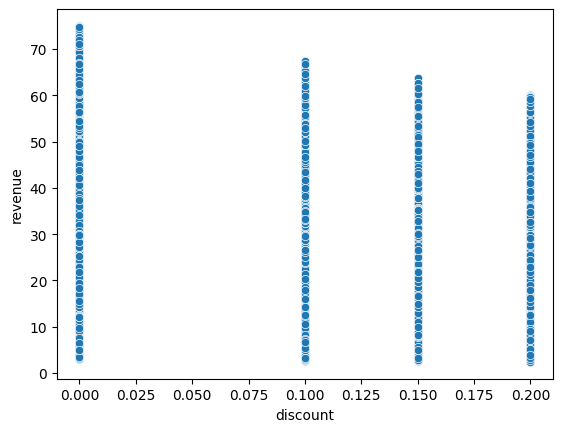

In [35]:
sns.scatterplot(data=df, x='discount', y='revenue')

# **KPI METRICS**

In [36]:
total_revenue = round(df['revenue'].sum(), 2)
total_profit = round(df['profit'].sum(), 2)
total_orders = df['order_id'].nunique()

total_revenue, total_profit, total_orders

(np.float64(25238648.22), np.float64(10095641.91), 990236)

In [37]:
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")

Total Revenue: $25,238,648.22
Total Profit: $10,095,641.91
Total Orders: 990,236


In [38]:
kpi = pd.DataFrame({"Metric":["Total Revenue","Total Profit","Total Orders"],
                    "Value":[total_revenue,total_profit,total_orders]})

kpi

,Metric,Value
0,Total Revenue,25238648.22
1,Total Profit,10095641.91
2,Total Orders,990236.00


# **Time Analysis**

In [39]:
monthly_sales = df.groupby(['year','month'])['revenue'].sum().reset_index()
monthly_sales.head()

,year,month,revenue
0,2023,1,1084177.53
1,2023,2,959873.03
2,2023,3,1074291.06
3,2023,4,1028124.89
4,2023,5,1073192.48


**Monthly Sales Trends**

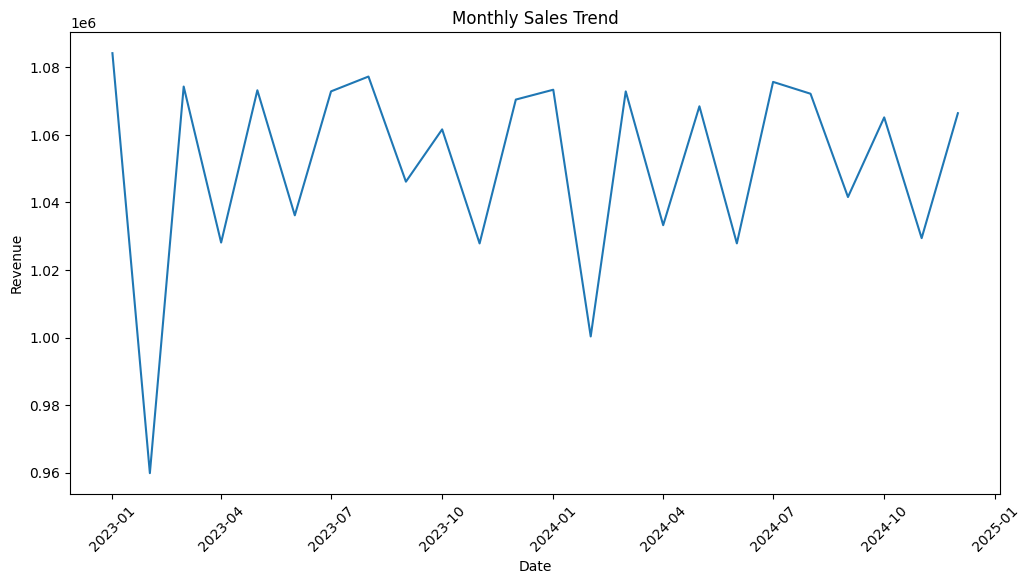

In [40]:
monthly_sales['date'] = pd.to_datetime(monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str))

plt.figure(figsize=(12,6))

plt.plot(monthly_sales['date'], monthly_sales['revenue'])

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

*"The monthly chocolate sales trend shows fluctuating revenue patterns, with an initial peak in early 2023 followed by a noticeable dip around April. Sales gradually recover through mid-2023 and remain relatively stable with slight growth toward the end of the year. A similar pattern continues into 2024, suggesting possible seasonality in chocolate demand or the impact of promotions and festive periods on sales."*

# **Product Analysis**

In [41]:
top_products = df.groupby('product_name')['revenue'].sum().reset_index()
top_products = top_products.sort_values(by='revenue',ascending=False).head(10)

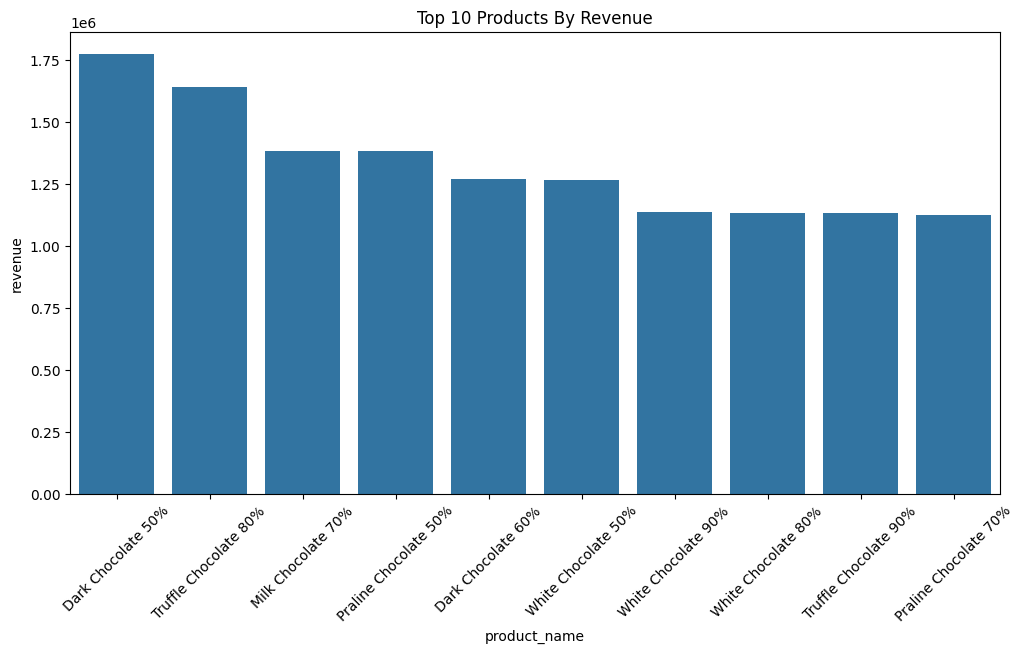

In [42]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_products,x='product_name',y='revenue')
plt.title("Top 10 Products By Revenue")
plt.xticks(rotation=45)
plt.show()

*The presence of multiple chocolate categories such as dark, milk, and truffle among the top-performing products suggests that revenue is not dominated by a single segment. Instead, it reflects a broad customer preference across different chocolate types and cocoa intensities. This highlights the importance of maintaining a diverse product portfolio to maximize sales*

# **Catagory Analysis**

In [43]:
category_sales = df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
category_sales['percentage'] = (category_sales['revenue'] / category_sales['revenue'].sum()) * 100
category_sales['revenue_lakh'] = category_sales['revenue'] / 100000


category_sales

,category,revenue,percentage,revenue_lakh
0,Praline,6665641.32,26.410453,66.656413
1,White,6070172.20,24.051099,60.701722
2,Dark,5298123.27,20.992104,52.981233
3,Truffle,3924343.24,15.548944,39.243432
4,Milk,3280368.19,12.997401,32.803682


**Categories By Chocolates Total Revenues**

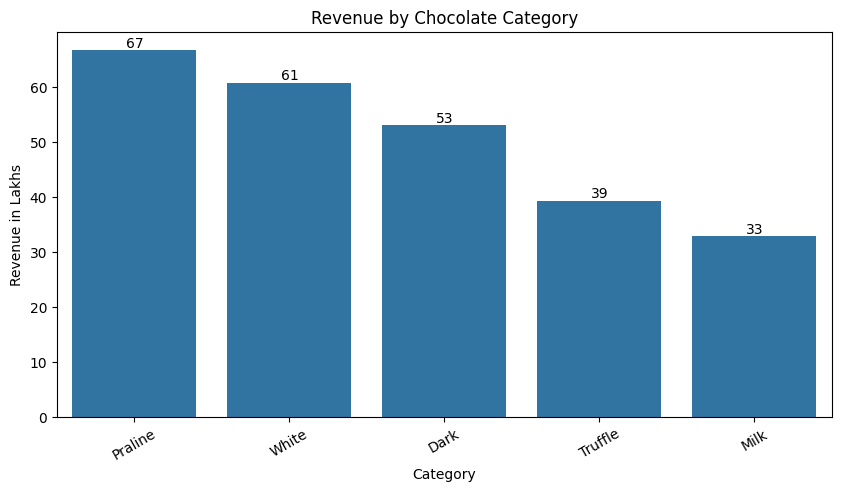

In [44]:


plt.figure(figsize=(10,5))

ax = sns.barplot(data=category_sales, x='category', y='revenue_lakh')
for i in ax.containers:
  ax.bar_label(i,fmt='%.0f')

plt.title("Revenue by Chocolate Category")
plt.xlabel("Category")
plt.ylabel("Revenue in Lakhs")
plt.xticks(rotation=30)
plt.show()

*"The category-wise revenue analysis shows that Praline chocolates generate the highest revenue, followed by White and Dark categories. This indicates that Praline is the most preferred category among customers, while Milk and Truffle contribute relatively less to overall sales."*

**Chocolates Category wise contribution**

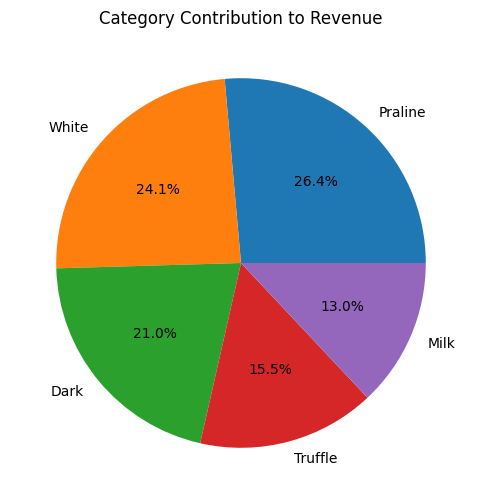

In [45]:
plt.figure(figsize=(6,6))

plt.pie(category_sales['revenue'],labels = category_sales['category'],autopct='%1.1f%%')
plt.title('Category Contribution to Revenue')
plt.show()

# **LOCATION ANALYSIS**

**Total Revenue of Chocolates of Top 10 cities**

In [46]:
city_sales = df.groupby('city')['revenue'].sum().sort_values(ascending=False).reset_index()
top_cities = city_sales.head(10).copy()
top_cities['revenue_lakh'] = top_cities['revenue'] / 100000

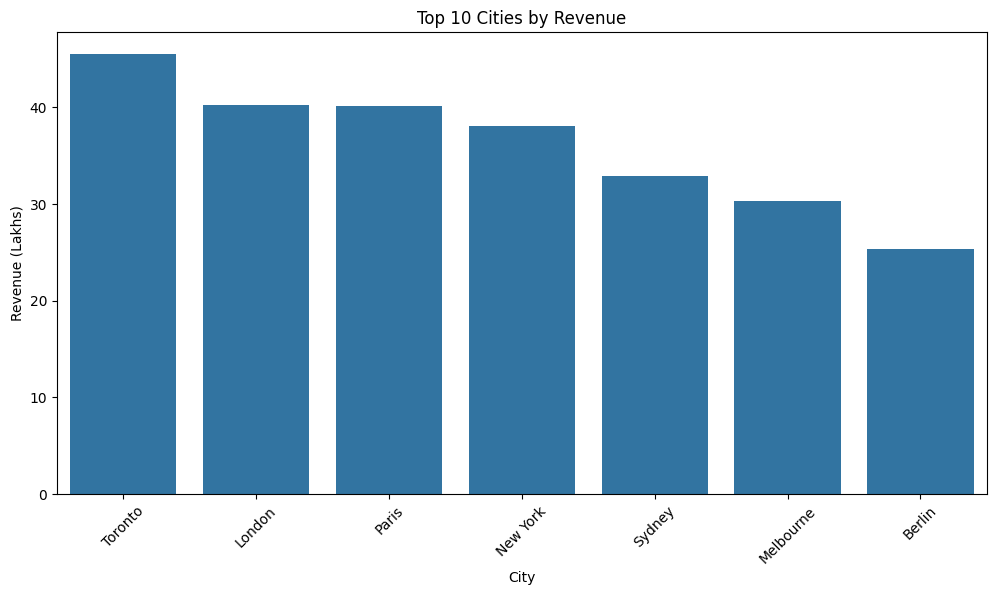

In [47]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_cities,x='city',y='revenue_lakh')

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue (Lakhs)")

plt.xticks(rotation=45)
plt.show()

*The city-wise revenue analysis shows that a few key cities contribute significantly to overall sales. These top-performing cities represent major revenue hubs and should be prioritized for marketing and business expansion strategies.*

**Total Revenue of Chocolates Country Wise**

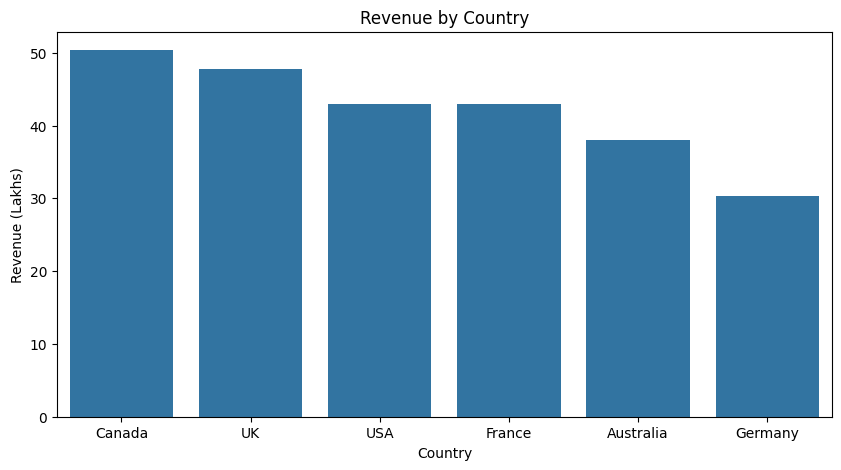

In [48]:
country_sales = df.groupby('country')['revenue'].sum().sort_values(ascending=False).reset_index()

country_sales['revenue_lakh'] = country_sales['revenue'] / 100000


plt.figure(figsize=(10,5))

sns.barplot(data=country_sales, x='country', y='revenue_lakh')

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue (Lakhs)")

plt.show()

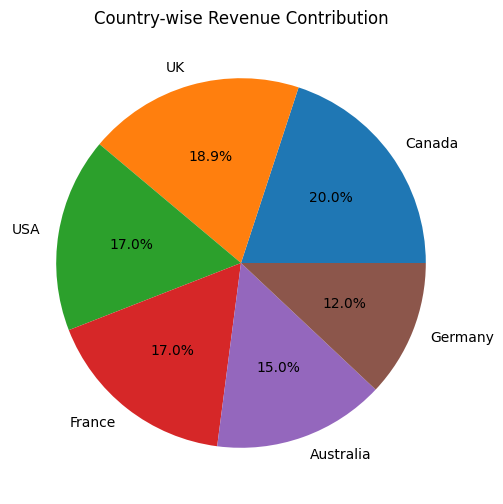

In [49]:
plt.figure(figsize=(6,6))

plt.pie(country_sales['revenue'],
        labels=country_sales['country'],
        autopct='%1.1f%%')

plt.title("Country-wise Revenue Contribution")

plt.show()

*Country-wise analysis shows that Canada generates the highest revenue, followed by the UK and USA. This indicates strong market performance in these regions, while countries like Germany and Australia contribute comparatively less to overall sales*

# **Customer Analysis**

**Total Revenue Gender Wise**

In [50]:
gender_sales = df.groupby('gender')['revenue'].sum().reset_index()
gender_sales['revenue_sales'] = gender_sales['revenue'] / 100000
gender_sales

,gender,revenue,revenue_sales
0,Female,12507747.89,125.077479
1,Male,12730900.33,127.309003


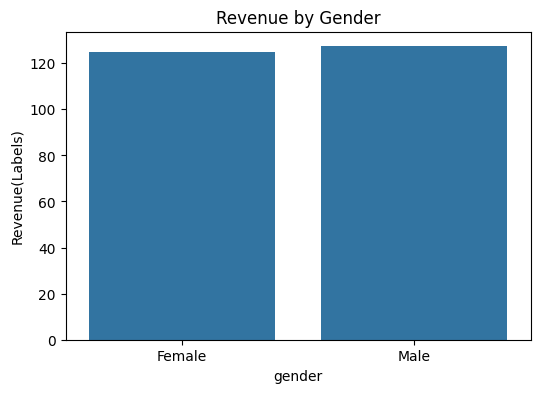

In [51]:
plt.figure(figsize=(6,4))
sns.barplot(data = gender_sales,x='gender',y='revenue_sales')

plt.title('Revenue by Gender')
plt.ylabel('Revenue(Labels)')

plt.show()

*"Revenue contribution from male and female customers is relatively balanced, indicating that chocolate products appeal equally across genders."*

**Total Revenue By Age Group**

In [52]:
df['age_group'] = pd.cut(df['age'],bins = [18,25,35,50,70],labels=['18-25','26-35','36-50','50+'])
age_sales = df.groupby('age_group')['revenue'].sum().reset_index()
age_sales['revenue_lakh'] = age_sales['revenue'] / 100000
age_sales

/tmp/ipykernel_2955/1604747632.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby('age_group')['revenue'].sum().reset_index()


,age_group,revenue,revenue_lakh
0,18-25,3364501.58,33.645016
1,26-35,4687656.66,46.876567
2,36-50,7159790.07,71.597901
3,50+,9545285.04,95.452850


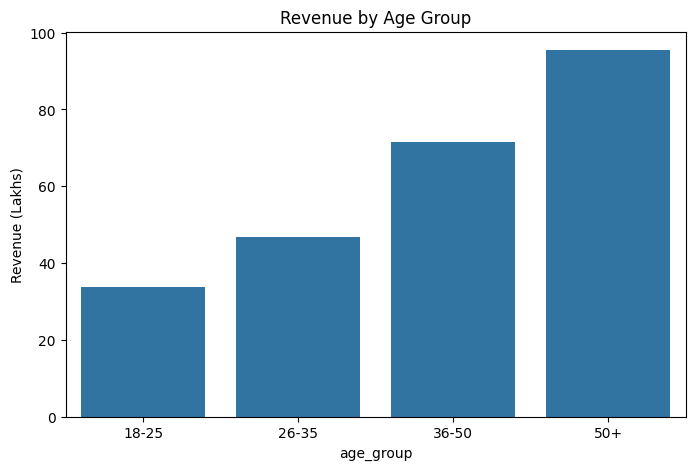

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(data=age_sales, x='age_group', y='revenue_lakh')

plt.title("Revenue by Age Group")
plt.ylabel("Revenue (Lakhs)")

plt.show()

**Loyalty Wise Total Revenue**

In [54]:
df['loyalty_member'] = df['loyalty_member'].replace({0: 'Non-Member', 1: 'Member'})

In [55]:

loyalty_sales = df.groupby('loyalty_member')['revenue'].sum().reset_index()

loyalty_sales['revenue_lakh'] = loyalty_sales['revenue'] / 100000
loyalty_sales

,loyalty_member,revenue,revenue_lakh
0,Member,12648035.38,126.480354
1,Non-Member,12590612.84,125.906128


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

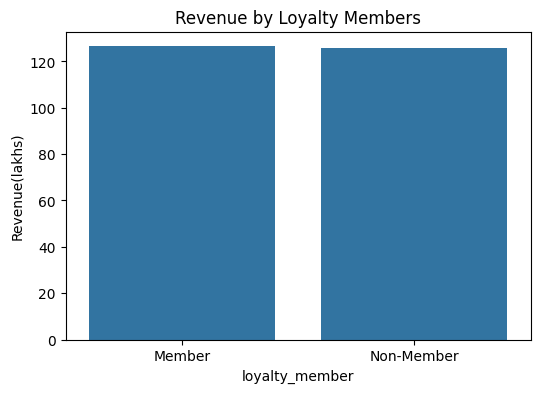

In [56]:
plt.figure(figsize=(6,4))

sns.barplot(data=loyalty_sales,x='loyalty_member',y='revenue_lakh')
plt.title('Revenue by Loyalty Members')
plt.ylabel('Revenue(lakhs)')

plt

**Correlation Heat Map**

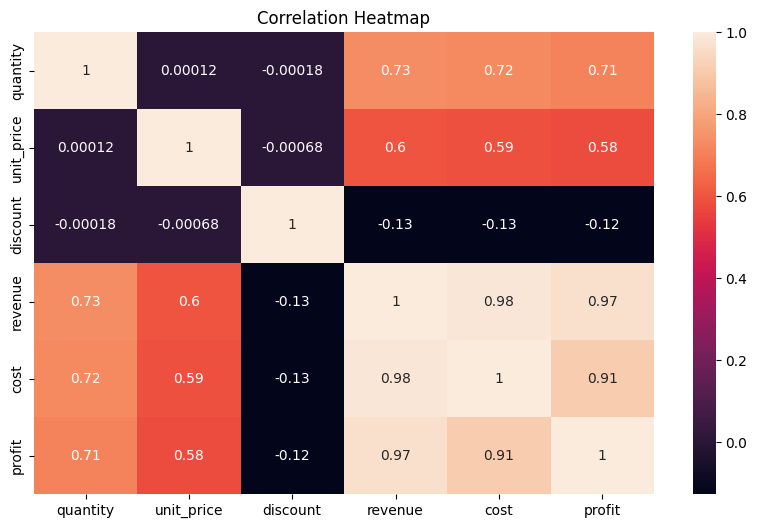

In [57]:
plt.figure(figsize=(10,6))
corr = df[['quantity','unit_price','discount','revenue','cost','profit']].corr()
sns.heatmap(corr,annot=True)

plt.title("Correlation Heatmap")
plt.show()

*Revenue and profit show a strong positive correlation, while discount has a negative relationship with profit, indicating that higher discounts may reduce profitability*

**Discount Vs Profit**

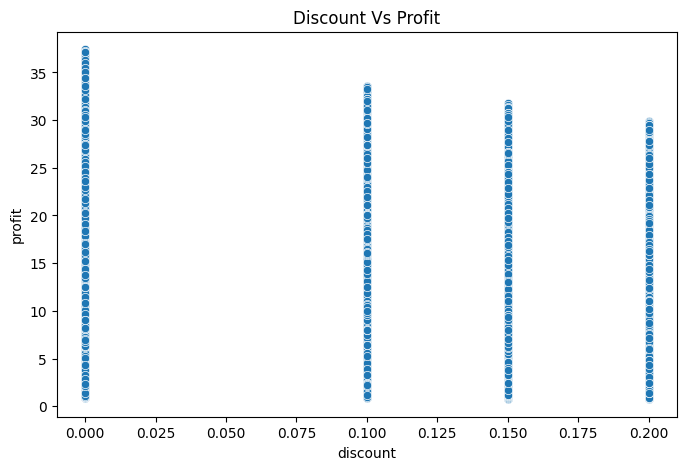

In [58]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,x="discount",y="profit")

plt.title("Discount Vs Profit")

plt.show()

*Higher discounts tend to reduce profit margins, suggesting that aggressive discounting strategies may negatively impact profitability*

**Distribution Plot(Histogram)**

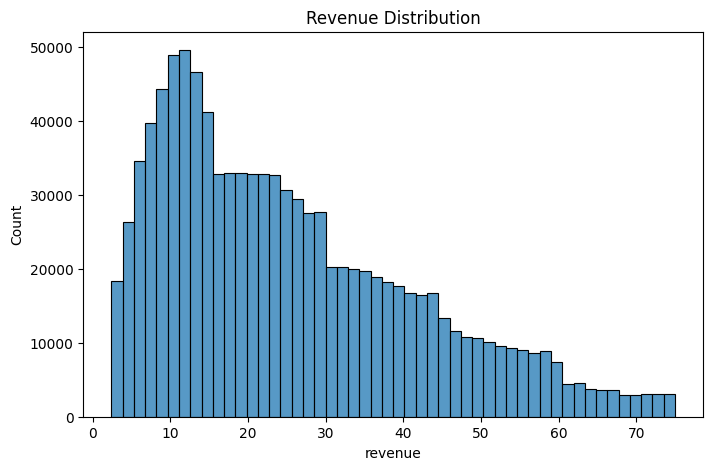

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(df['revenue'],bins = 50)

plt.title("Revenue Distribution")

plt.show()

In [60]:
features = df[['age','quantity','revenue']]

**Scaling**

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler_data = scaler.fit_transform(features)


**Kmeans Clustering**

In [62]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3,random_state = 42)

df['cluster'] = kmeans.fit_predict(scaler_data)

*KMeans clustering identified distinct customer segments based on purchasing behavior, enabling targeted marketing strategies.*

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


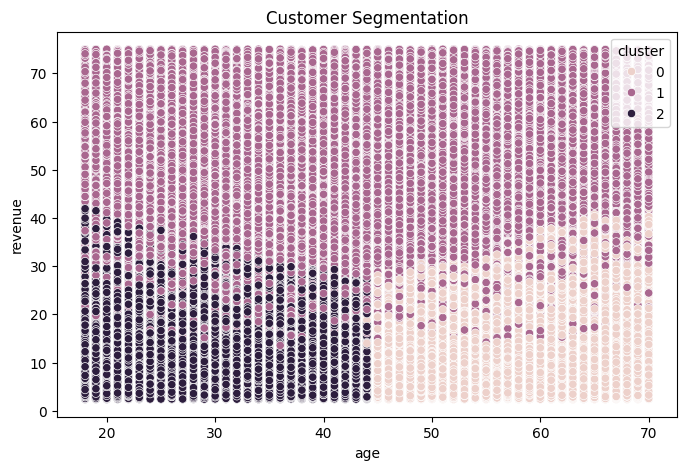

In [63]:

plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='age', y='revenue', hue='cluster')

plt.title("Customer Segmentation")

plt.show()

*Customer segmentation reveals that older customers (Cluster 0) fall within the 50–70 age range with moderate spending behavior, while younger customers (Cluster 2) represent a low to mid-revenue segment. Cluster 1 dominates across all age groups, indicating a large group of average customers contributing consistently to revenue. This suggests that while distinct segments exist, the majority of revenue comes from a broadly distributed customer base rather than a single high-value segment*

In [64]:
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters = i,random_state = 42)
  kmeans.fit(scaler_data)
  wcss.append(kmeans.inertia_)

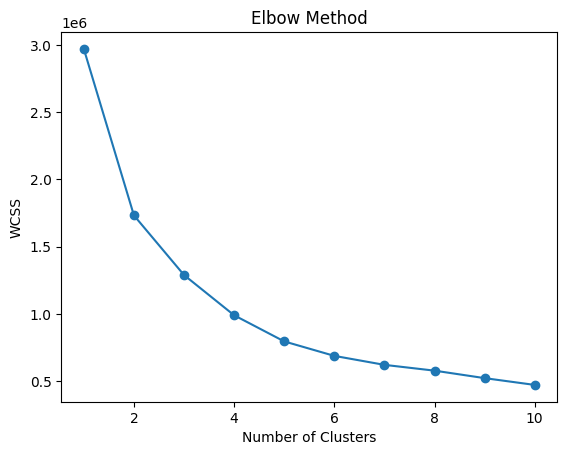

In [65]:
plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

**Forecasting**

In [66]:
ts = df.groupby('order_date')['revenue'].sum()
ts_monthly = ts.resample('M').sum()


/tmp/ipykernel_2955/1733383221.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_monthly = ts.resample('M').sum()


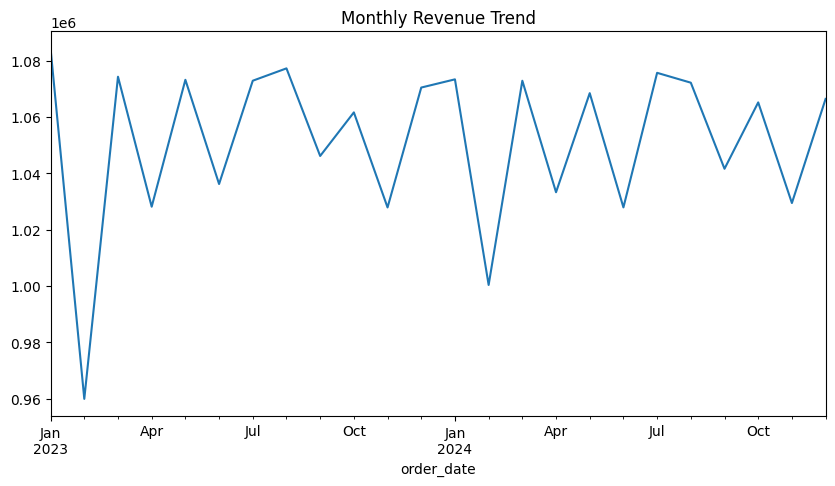

In [67]:
ts_monthly.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

In [68]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(ts_monthly,order=(1,1,1))
model_fit = model.fit()



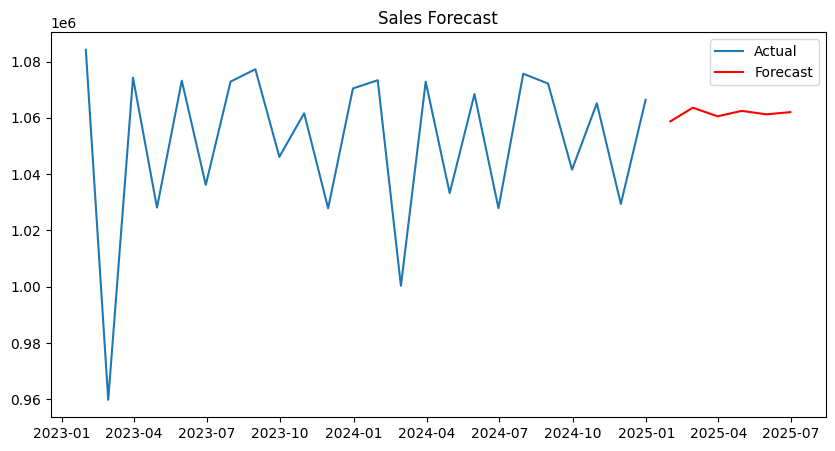

In [69]:
forecast = model_fit.forecast(steps = 6)

plt.figure(figsize=(10,5))
plt.plot(ts_monthly,label='Actual')
plt.plot(forecast,label='Forecast',color='red')

plt.legend()
plt.title('Sales Forecast')

plt.show()

*The forecasting model predicts a steady trend in revenue for the upcoming months, indicating consistent sales performance with no major fluctuations expected.*

In [70]:
!pip install prophet

In [71]:
from prophet import Prophet

In [72]:
ts = df.groupby('order_date')['revenue'].sum().reset_index()

ts.columns = ['ds','y']

In [73]:
model = Prophet()
model.fit(ts)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [74]:
future = model.make_future_dataframe(periods=6, freq='M')

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [75]:
forecast = model.predict(future)

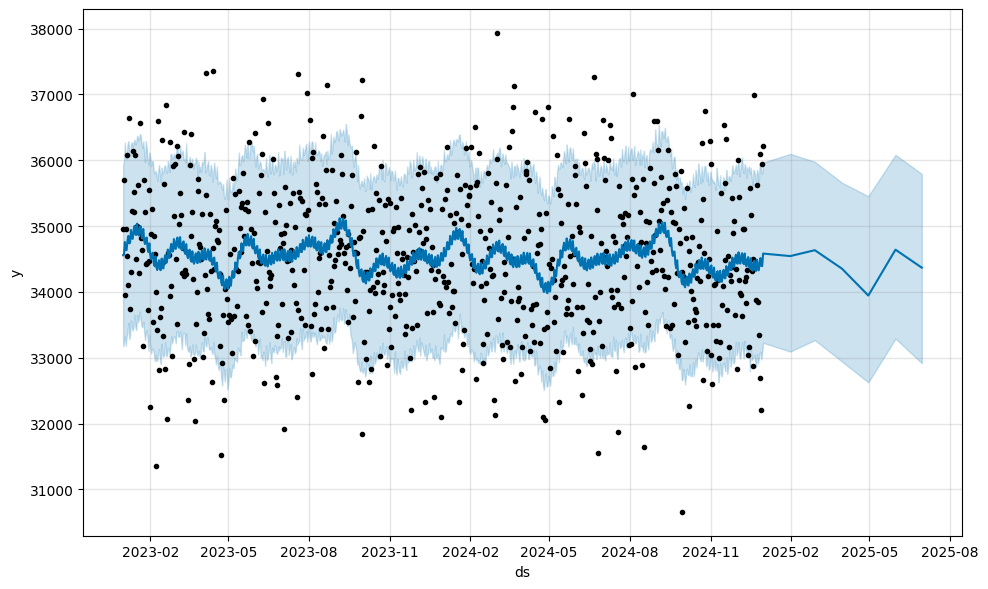

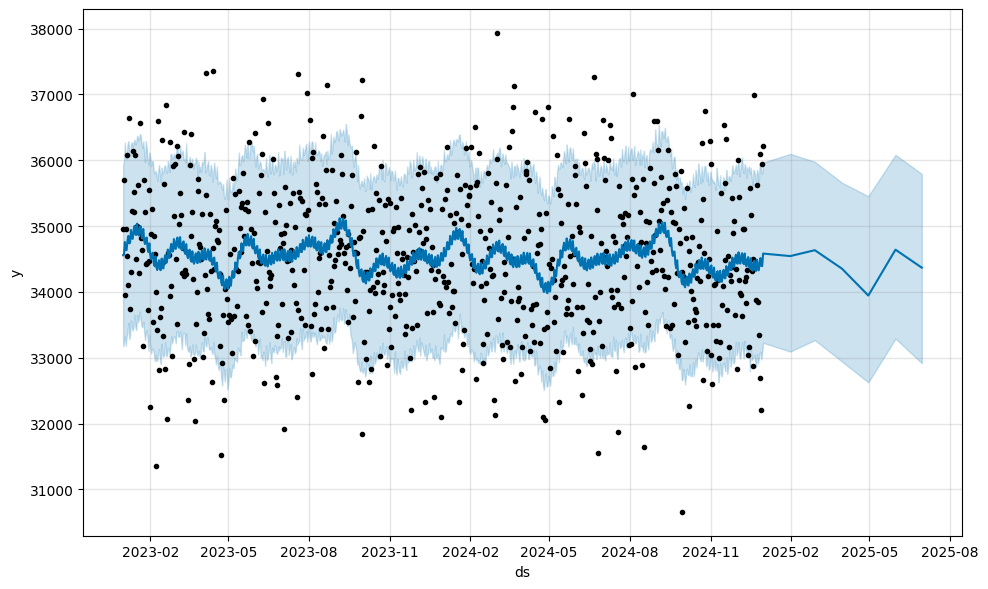

In [76]:
model.plot(forecast)

*The forecast shows a relatively stable trend in revenue with slight fluctuations, indicating consistent business performance over time. The confidence interval suggests moderate uncertainty in future predictions*

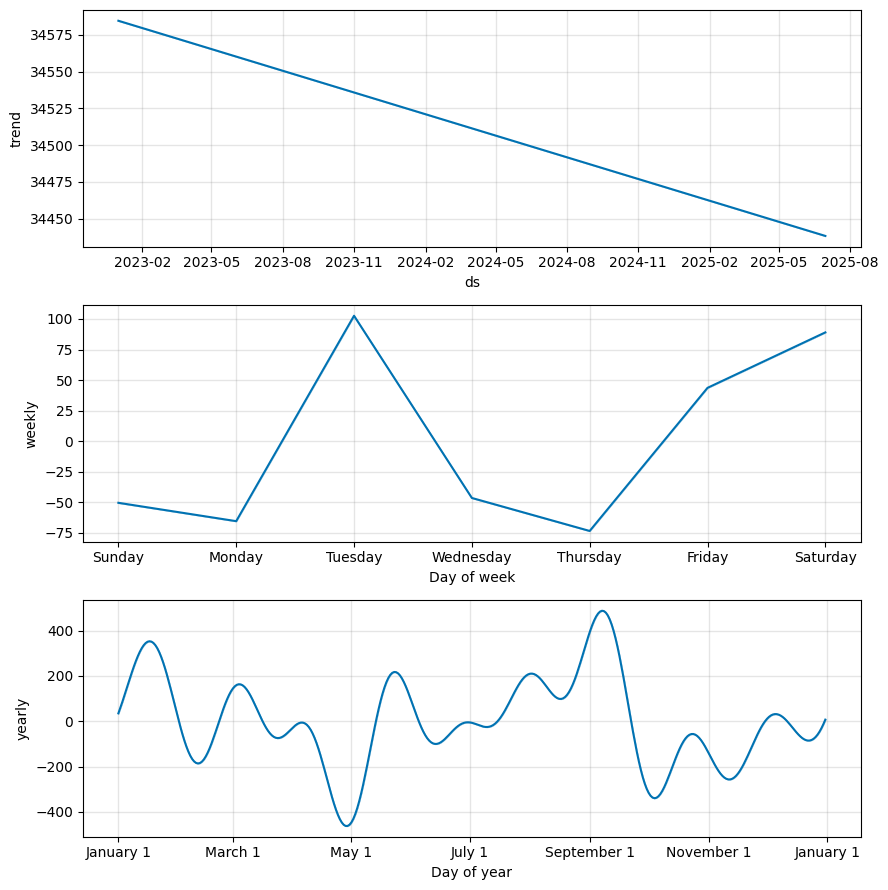

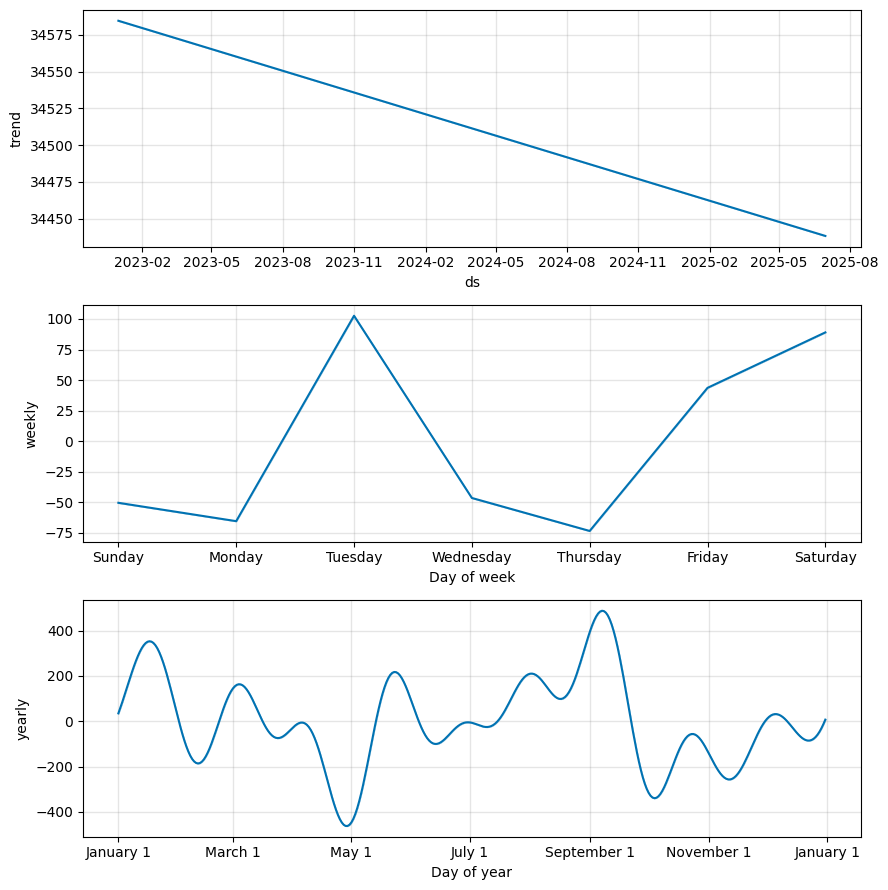

In [77]:
model.plot_components(forecast)

*The time series analysis reveals multiple important patterns in chocolate sales. The overall trend shows a gradual decline in revenue over time, indicating a potential slowdown in overall sales performance. However, the yearly seasonality highlights strong growth phases, with sales increasing significantly from the beginning of the year and peaking around September, followed by a sharp decline towards the start of the next year. This suggests the presence of seasonal demand patterns, possibly influenced by external factors such as holidays or promotions. Additionally, the weekly seasonality indicates structured customer purchasing behavior, with sales peaking on Tuesdays, dropping on Thursdays, and stabilizing during weekends. These insights suggest opportunities for targeted marketing strategies, especially to improve low-performing periods and capitalize on peak demand phases*

**Model Tuning**

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


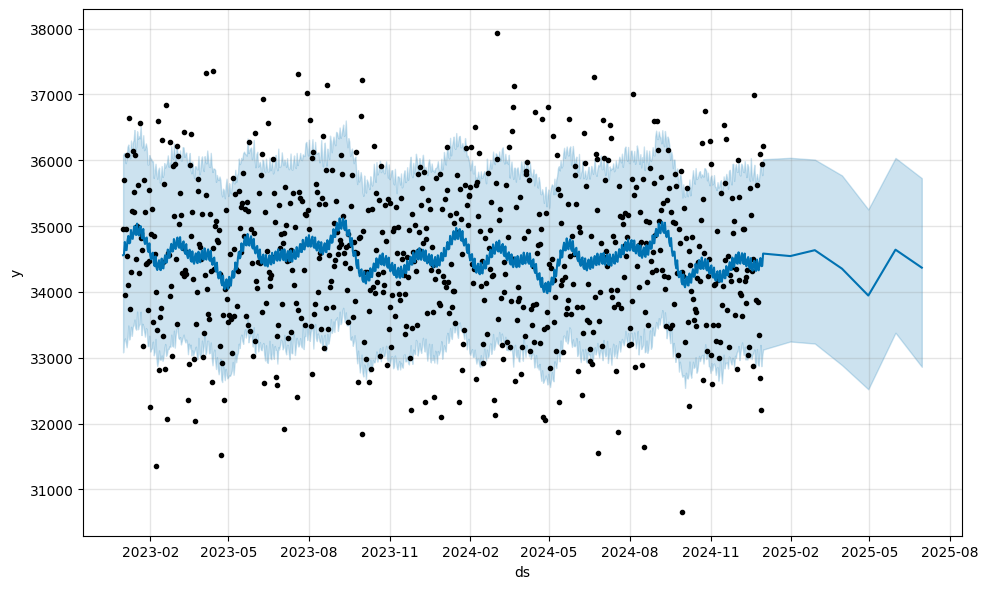

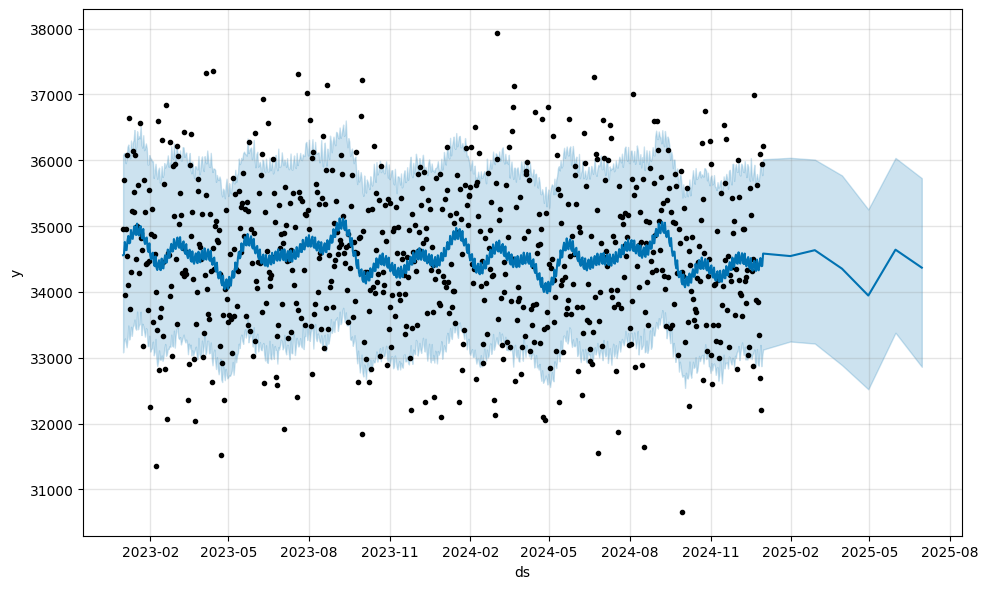

In [78]:
model_tuned = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_tuned.fit(ts)

future = model_tuned.make_future_dataframe(periods=6, freq='M')
forecast_tuned = model_tuned.predict(future)

model_tuned.plot(forecast_tuned)

In [79]:
from prophet.diagnostics import cross_validation

cv_results = cross_validation(
    model_tuned,
    initial='365 days',
    period='180 days',
    horizon='90 days'
)

INFO:prophet:Making 2 forecasts with cutoffs between 2024-04-05 00:00:00 and 2024-10-02 00:00:00


  0%|          | 0/2 [00:00<?, ?it/s]

In [80]:
from prophet.diagnostics import performance_metrics

performance_metrics(cv_results)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,9 days,8.786722e+05,937.375165,792.140427,0.023214,0.021616,0.023153,0.833333
1,10 days,1.135356e+06,1065.530675,836.121356,0.024281,0.018405,0.024344,0.833333
2,11 days,1.145987e+06,1070.508012,838.674240,0.024414,0.021616,0.024450,0.833333
3,12 days,9.493112e+05,974.326048,731.250465,0.021462,0.014735,0.021407,0.888889
4,13 days,9.131625e+05,955.595382,713.923323,0.020883,0.014735,0.020867,0.888889
...,...,...,...,...,...,...,...,...
77,86 days,1.793832e+06,1339.340177,1087.132943,0.031542,0.029365,0.031563,0.666667
78,87 days,2.325024e+06,1524.803086,1298.240443,0.037562,0.032918,0.037656,0.555556
79,88 days,2.506193e+06,1583.096141,1345.795375,0.039051,0.032918,0.039107,0.555556
80,89 days,2.115429e+06,1454.451495,1206.419318,0.035302,0.031108,0.035209,0.611111


*The analysis reveals a slightly declining overall trend in revenue, indicating a gradual slowdown in sales over time. However, strong seasonal patterns are observed, with sales peaking around September and declining towards the beginning of the year. Weekly patterns highlight higher customer activity on Tuesdays, a dip on Thursdays, and stable performance during weekends. The forecasting model built using Prophet captures these trends and seasonality effectively, with cross-validation results showing low error rates (MAPE around 2–3%), indicating reliable predictive performance. These insights suggest opportunities to optimize sales through targeted promotions during low-performing periods and maximizing revenue during peak seasons*

In [81]:
df.to_csv("final_chocolate_sales.csv",index = False)

In [82]:
df.to_csv("final_data_clean.csv", index=False, encoding='utf-8-sig')

In [ ]:
df.to_csv("final_data.csv.gz", index=False, compression='gzip')